In [7]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)
print('Libraries loaded successfully!')
print(f'TensorFlow version: {tf.__version__}')

Libraries loaded successfully!
TensorFlow version: 2.20.0


---
1a. Eksplorasi Data & Preprocessing

In [8]:
# Load datasets
amd  = pd.read_csv('../data/AMD.csv',  parse_dates=['Date'])
aapl = pd.read_csv('../data/AAPL.csv', parse_dates=['Date'])

print('=== AMD Dataset ===')
print(f'Shape: {amd.shape}')
print(f'Date range: {amd["Date"].min().date()} → {amd["Date"].max().date()}')
print(amd.head(3))

print('\n=== AAPL Dataset ===')
print(f'Shape: {aapl.shape}')
print(f'Date range: {aapl["Date"].min().date()} → {aapl["Date"].max().date()}')
print(aapl.head(3))

=== AMD Dataset ===
Shape: (10098, 7)
Date range: 1980-03-17 → 2020-04-01
        Date  Open      High       Low     Close  Adj Close  Volume
0 1980-03-17   0.0  3.302083  3.125000  3.145833   3.145833  219600
1 1980-03-18   0.0  3.125000  2.937500  3.031250   3.031250  727200
2 1980-03-19   0.0  3.083333  3.020833  3.041667   3.041667  295200

=== AAPL Dataset ===
Shape: (9909, 7)
Date range: 1980-12-12 → 2020-04-01
        Date      Open      High       Low     Close  Adj Close     Volume
0 1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1 1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2 1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000


Missing values AMD : 0
Missing values AAPL: 0


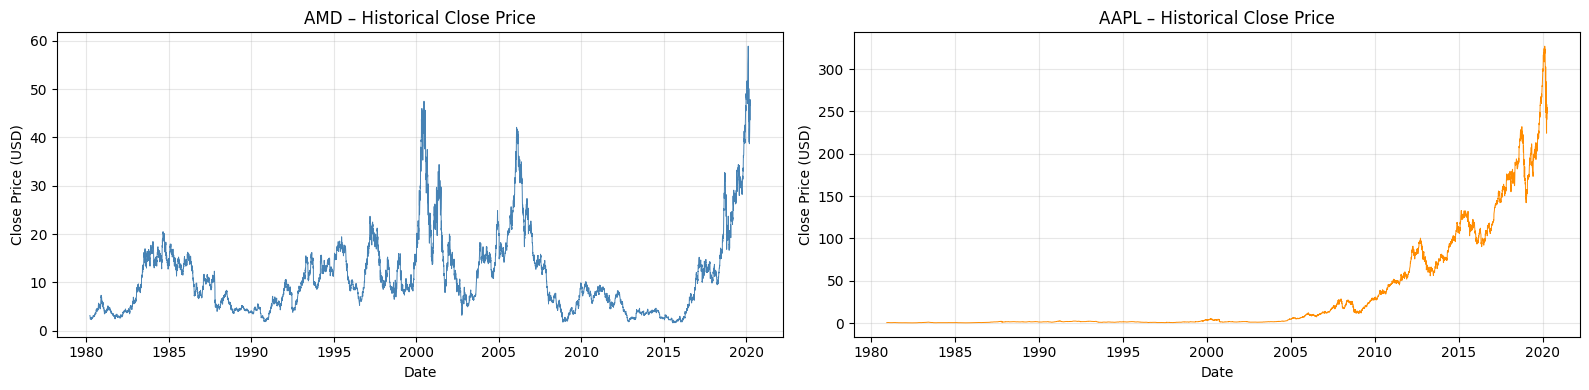

In [9]:
# Gunakan hanya kolom Date dan Close
amd_df  = amd[['Date','Close']].sort_values('Date').reset_index(drop=True)
aapl_df = aapl[['Date','Close']].sort_values('Date').reset_index(drop=True)

# Cek missing values
print('Missing values AMD :', amd_df.isnull().sum().sum())
print('Missing values AAPL:', aapl_df.isnull().sum().sum())

# Plot seluruh data
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, df, ticker, color in zip(axes, [amd_df, aapl_df], ['AMD','AAPL'], ['steelblue','darkorange']):
    ax.plot(df['Date'], df['Close'], linewidth=0.7, color=color)
    ax.set_title(f'{ticker} – Historical Close Price')
    ax.set_xlabel('Date'); ax.set_ylabel('Close Price (USD)')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
def prepare_dataset(df, ticker):
    """
    Pipeline lengkap:
    1. Train/Test split (1 tahun terakhir = test)
    2. MinMax Scaling (fit pada train saja)
    3. Windowing: window_size=5, horizon=1
    4. Split train → 90% train_set + 10% val_set
    """
    WINDOW_SIZE = 5

    # Train/Test Split
    cutoff = df['Date'].max() - pd.DateOffset(years=1)
    train_df = df[df['Date'] <= cutoff]
    test_df  = df[df['Date'] >  cutoff]
    print(f'[{ticker}] Train: {len(train_df)} rows | Test: {len(test_df)} rows')

    # Scaling
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_df[['Close']].values)
    test_scaled  = scaler.transform(test_df[['Close']].values)

    # Windowing function
    def make_windows(arr):
        X, y = [], []
        for i in range(len(arr) - WINDOW_SIZE):
            X.append(arr[i:i+WINDOW_SIZE, 0])
            y.append(arr[i+WINDOW_SIZE, 0])
        return np.array(X), np.array(y)

    X_train_all, y_train_all = make_windows(train_scaled)

    # Untuk test: seed dari 5 hari terakhir training
    seed = train_scaled[-WINDOW_SIZE:]
    test_seq = np.concatenate([seed, test_scaled], axis=0)
    X_test, y_test = make_windows(test_seq)

    # Split 90% / 10%
    val_size   = int(len(X_train_all) * 0.10)
    train_size = len(X_train_all) - val_size
    X_tr, y_tr   = X_train_all[:train_size], y_train_all[:train_size]
    X_val, y_val = X_train_all[train_size:], y_train_all[train_size:]

    print(f'[{ticker}] X_train={X_tr.shape}, X_val={X_val.shape}, X_test={X_test.shape}')

    # Reshape untuk LSTM: (samples, timesteps=5, features=1)
    X_tr   = X_tr.reshape(*X_tr.shape,   1)
    X_val  = X_val.reshape(*X_val.shape,  1)
    X_test = X_test.reshape(*X_test.shape, 1)

    return X_tr, y_tr, X_val, y_val, X_test, y_test, scaler, train_df, test_df

amd_data  = prepare_dataset(amd_df,  'AMD')
aapl_data = prepare_dataset(aapl_df, 'AAPL')

[AMD] Train: 9845 rows | Test: 253 rows
[AMD] X_train=(8856, 5), X_val=(984, 5), X_test=(253, 5)
[AAPL] Train: 9656 rows | Test: 253 rows
[AAPL] X_train=(8686, 5), X_val=(965, 5), X_test=(253, 5)


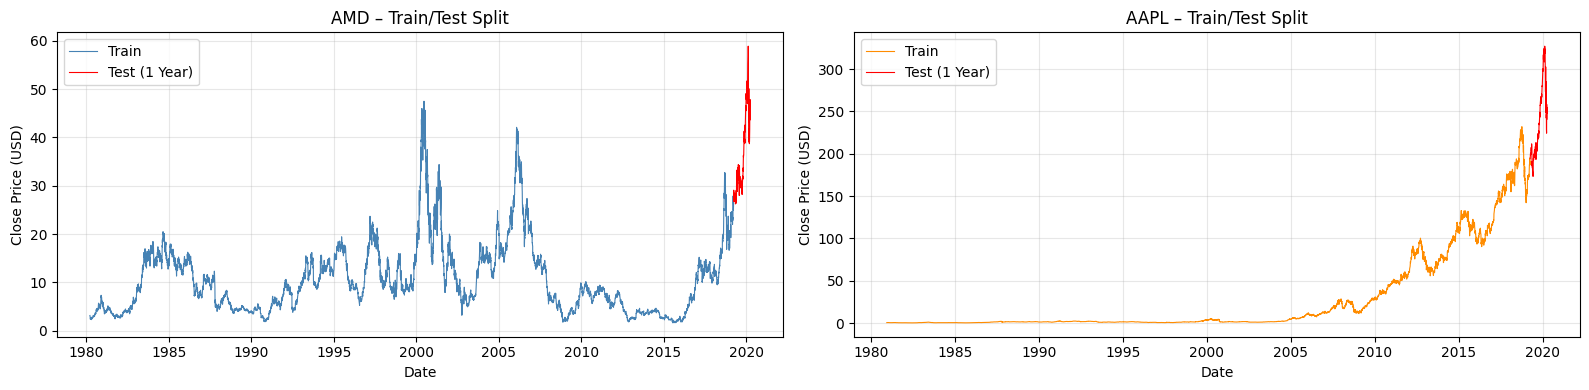

In [11]:
# Visualisasi Train/Test Split
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, data, ticker, color in zip(axes, [amd_data, aapl_data], ['AMD','AAPL'], ['steelblue','darkorange']):
    train_df, test_df = data[7], data[8]
    ax.plot(train_df['Date'], train_df['Close'], label='Train', color=color, linewidth=0.8)
    ax.plot(test_df['Date'],  test_df['Close'],  label='Test (1 Year)', color='red', linewidth=0.8)
    ax.set_title(f'{ticker} – Train/Test Split')
    ax.set_xlabel('Date'); ax.set_ylabel('Close Price (USD)')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
1b. Arsitektur Baseline LSTM

Arsitektur:
- **LSTM layer**: units=50, activation=ReLU
- **Dense (Perceptron) layer**: units=1 (output prediksi harga)
- **Optimizer**: Adam
- **Loss**: MSE

In [12]:
def build_baseline(window_size=5):
    model = Sequential([
        LSTM(units=50, activation='relu', input_shape=(window_size, 1)),
        Dense(units=1)
    ], name='Baseline_LSTM')
    model.compile(optimizer='adam', loss='mse')
    return model

def train_and_evaluate(X_tr, y_tr, X_val, y_val, X_test, y_test, scaler,
                        ticker, model, epochs=100, batch=32, patience=10, use_rlr=False):
    cbs = [EarlyStopping(patience=patience, restore_best_weights=True, monitor='val_loss')]
    if use_rlr:
        cbs.append(ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6))

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs, batch_size=batch,
        callbacks=cbs, verbose=0
    )
    print(f'[{ticker}] Training selesai di epoch {len(history.history["loss"])}')

    # Prediksi
    y_pred_s = model.predict(X_test, verbose=0)
    y_pred   = scaler.inverse_transform(y_pred_s).flatten()
    y_true   = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return history, y_pred, y_true, {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

# Train baseline AMD
amd_base = build_baseline()
amd_base.summary()
amd_base_hist, amd_base_pred, amd_base_true, amd_base_met = train_and_evaluate(
    *amd_data[:7], 'AMD', amd_base)

# Train baseline AAPL
aapl_base = build_baseline()
aapl_base_hist, aapl_base_pred, aapl_base_true, aapl_base_met = train_and_evaluate(
    *aapl_data[:7], 'AAPL', aapl_base)

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

[AMD] Training selesai di epoch 74
[AAPL] Training selesai di epoch 12


---
1c. Modifikasi Arsitektur LSTM

Alasan Modifikasi:
1. **Stacked LSTM (2 layers)**: Satu LSTM layer terbatas dalam menangkap pola temporal yang kompleks. Menambahkan layer kedua memungkinkan model mempelajari representasi hierarkis dari data time series – layer pertama belajar pola jangka pendek, layer kedua pola lebih abstrak/jangka panjang.
2. **Dropout (rate=0.2)**: Baseline cenderung overfit karena data training sangat panjang (30+ tahun). Dropout secara acak "mematikan" 20% neuron saat training, memaksa model belajar representasi yang lebih robust.
3. **Dense hidden layer (16 units)**: Menambahkan satu Dense layer sebelum output memberikan kapasitas non-linear tambahan untuk memetakan fitur LSTM ke prediksi harga.
4. **Batch size lebih kecil (16)**: Memberikan update gradien yang lebih sering dan lebih noisy, yang bisa membantu model keluar dari local minima.
5. **ReduceLROnPlateau**: Secara adaptif menurunkan learning rate saat training stagnan, memungkinkan konvergensi yang lebih baik ke minimum.
6. **EarlyStopping dengan patience=15**: Memberi model waktu lebih lama untuk belajar sambil tetap mencegah overfitting.

In [13]:
def build_modified(window_size=5):
    model = Sequential([
        # Layer LSTM pertama: return_sequences=True agar output diteruskan ke LSTM berikutnya
        LSTM(units=64, activation='relu', return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        # Layer LSTM kedua: menangkap pola temporal lebih dalam
        LSTM(units=32, activation='relu'),
        Dropout(0.2),
        # Dense hidden layer untuk transformasi non-linear tambahan
        Dense(units=16, activation='relu'),
        # Output layer: prediksi 1 harga ke depan
        Dense(units=1)
    ], name='Modified_LSTM')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse'
    )
    return model

# Train modified AMD
amd_mod = build_modified()
amd_mod.summary()
amd_mod_hist, amd_mod_pred, amd_mod_true, amd_mod_met = train_and_evaluate(
    *amd_data[:7], 'AMD', amd_mod, epochs=150, batch=16, patience=15, use_rlr=True)

# Train modified AAPL
aapl_mod = build_modified()
aapl_mod_hist, aapl_mod_pred, aapl_mod_true, aapl_mod_met = train_and_evaluate(
    *aapl_data[:7], 'AAPL', aapl_mod, epochs=150, batch=16, patience=15, use_rlr=True)

Model: "Modified_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 5, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

[AMD] Training selesai di epoch 20


[AAPL] Training selesai di epoch 18


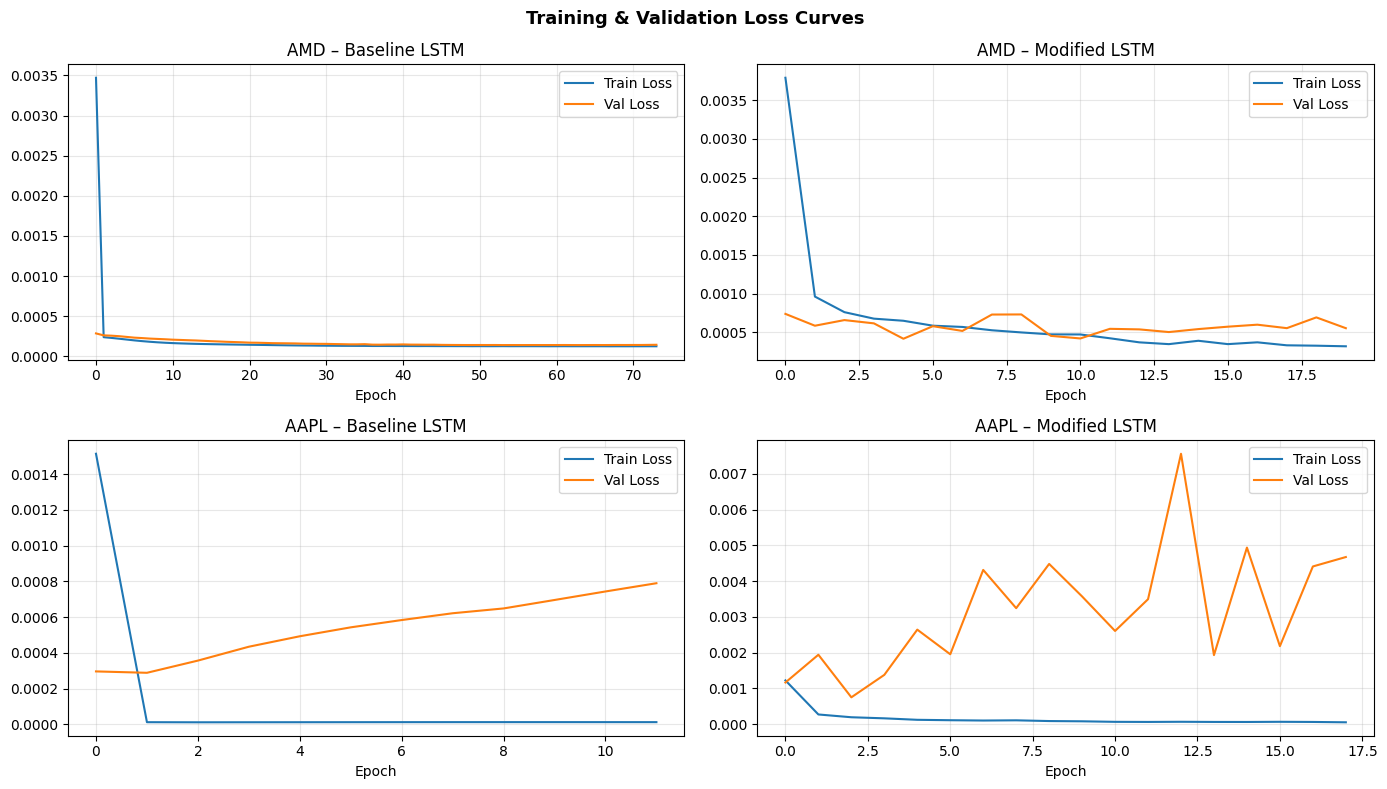

In [14]:
# Plot Loss Curves
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Training & Validation Loss Curves', fontsize=13, fontweight='bold')

pairs = [(amd_base_hist, amd_mod_hist, 'AMD'), (aapl_base_hist, aapl_mod_hist, 'AAPL')]
for idx, (h_b, h_m, ticker) in enumerate(pairs):
    axes[idx,0].plot(h_b.history['loss'],     label='Train Loss')
    axes[idx,0].plot(h_b.history['val_loss'], label='Val Loss')
    axes[idx,0].set_title(f'{ticker} – Baseline LSTM')
    axes[idx,0].set_xlabel('Epoch'); axes[idx,0].legend(); axes[idx,0].grid(alpha=0.3)

    axes[idx,1].plot(h_m.history['loss'],     label='Train Loss')
    axes[idx,1].plot(h_m.history['val_loss'], label='Val Loss')
    axes[idx,1].set_title(f'{ticker} – Modified LSTM')
    axes[idx,1].set_xlabel('Epoch'); axes[idx,1].legend(); axes[idx,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

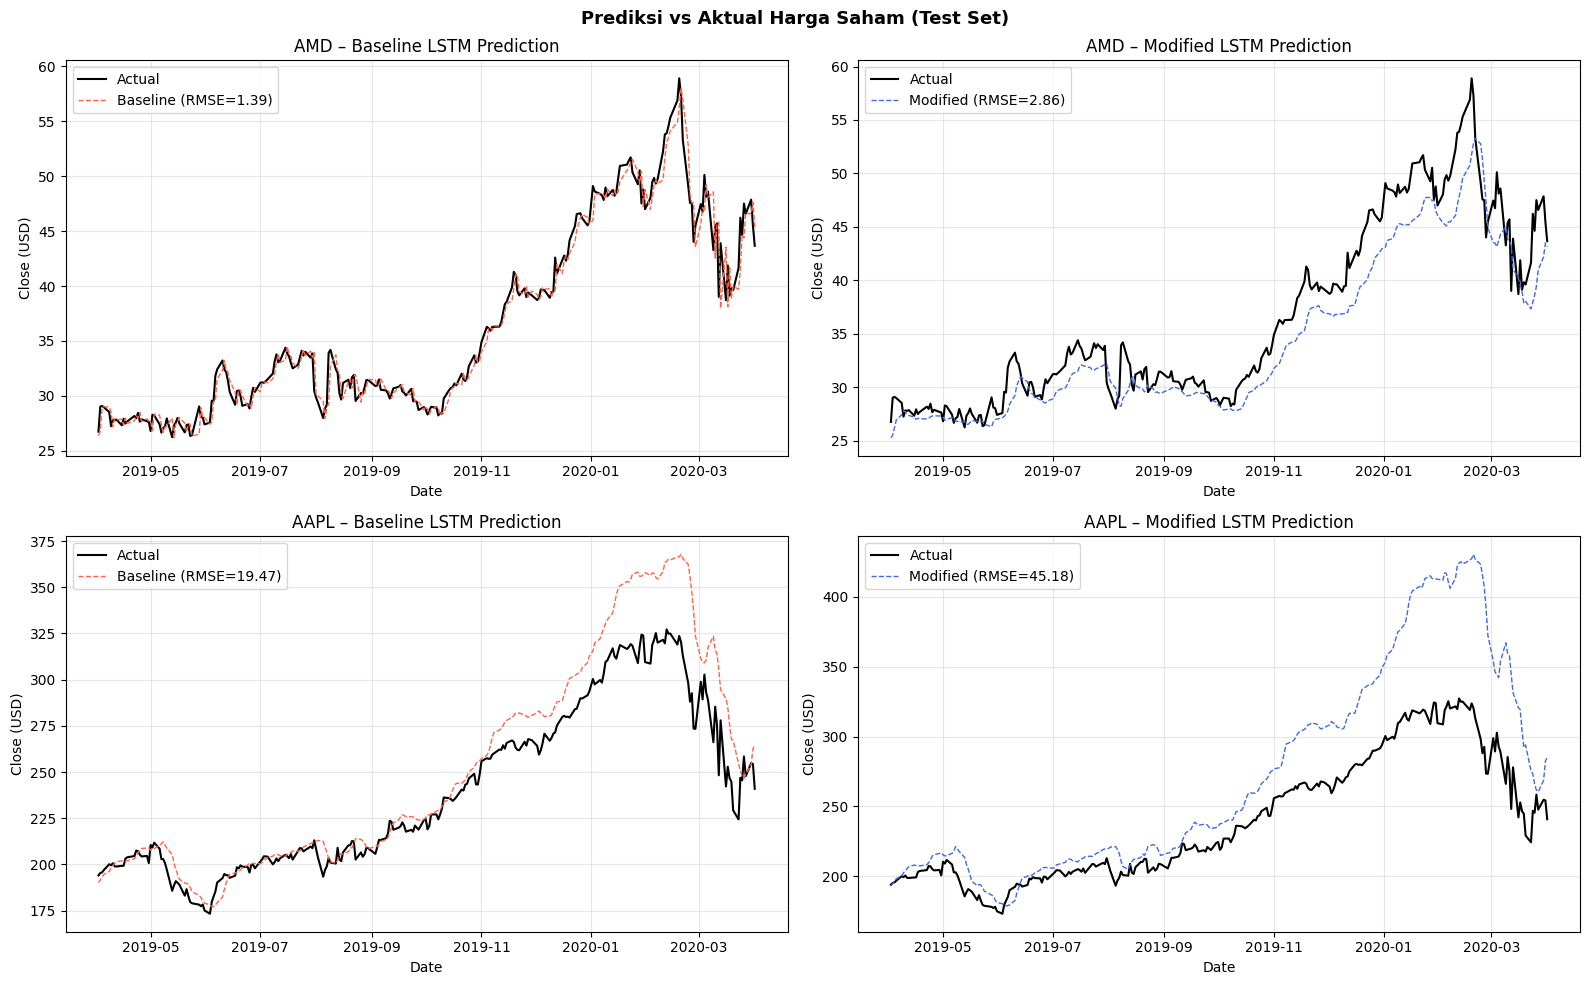

In [15]:
# Plot Predictions vs Actual
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Prediksi vs Aktual Harga Saham (Test Set)', fontsize=13, fontweight='bold')

for idx, (true_b, base_p, mod_p, data, ticker, bm, mm) in enumerate([
    (amd_base_true,  amd_base_pred,  amd_mod_pred,  amd_data,  'AMD',  amd_base_met,  amd_mod_met),
    (aapl_base_true, aapl_base_pred, aapl_mod_pred, aapl_data, 'AAPL', aapl_base_met, aapl_mod_met)
]):
    dates = data[8]['Date'].values

    ax = axes[idx, 0]
    ax.plot(dates, true_b, label='Actual', color='black', linewidth=1.5)
    ax.plot(dates, base_p, label=f'Baseline (RMSE={bm["RMSE"]:.2f})', color='tomato', linestyle='--', linewidth=1)
    ax.set_title(f'{ticker} – Baseline LSTM Prediction')
    ax.set_xlabel('Date'); ax.set_ylabel('Close (USD)')
    ax.legend(); ax.grid(alpha=0.3)

    ax = axes[idx, 1]
    ax.plot(dates, true_b, label='Actual', color='black', linewidth=1.5)
    ax.plot(dates, mod_p,  label=f'Modified (RMSE={mm["RMSE"]:.2f})', color='royalblue', linestyle='--', linewidth=1)
    ax.set_title(f'{ticker} – Modified LSTM Prediction')
    ax.set_xlabel('Date'); ax.set_ylabel('Close (USD)')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
1d. Evaluasi Unjuk Kerja

EVALUASI METRIK – TEST SET
Ticker  Arsitektur           RMSE       MAE    MAPE (%)
-----------------------------------------------------------------
AMD     Baseline           1.3926    0.9133      2.4432
AMD     Modified           2.8611    2.2725      5.8123
-----------------------------------------------------------------
AAPL    Baseline          19.4709   12.7988      4.7790
AAPL    Modified          45.1782   31.8229     11.7745
-----------------------------------------------------------------


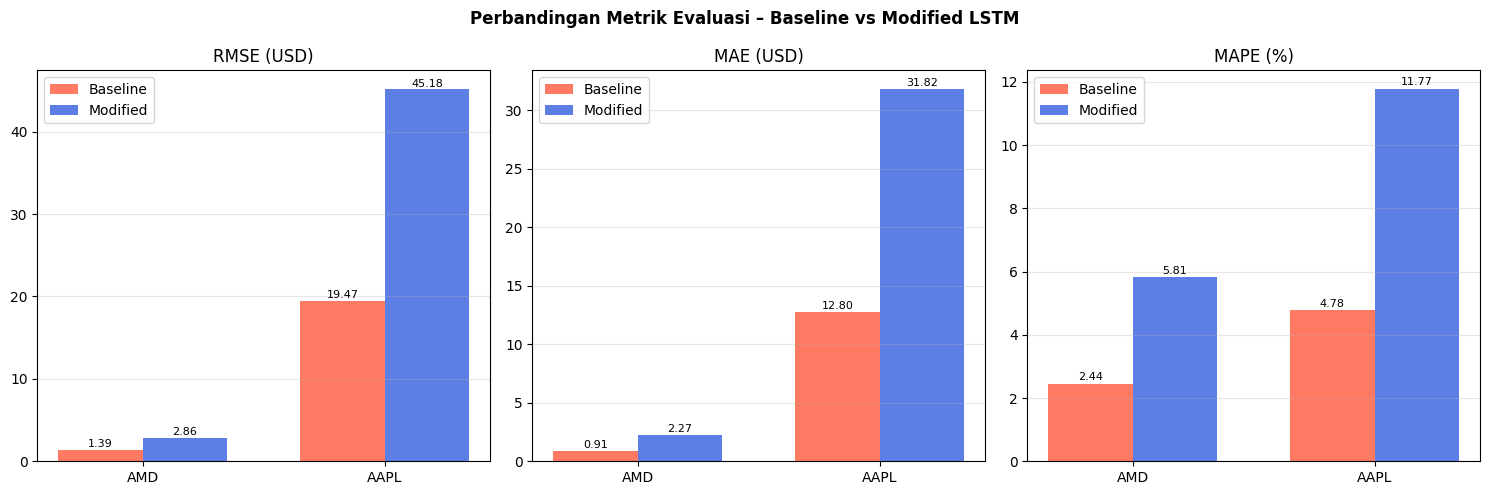

In [16]:
print('=' * 65)
print('EVALUASI METRIK – TEST SET')
print('=' * 65)
print(f'{"Ticker":<8}{"Arsitektur":<15}{"RMSE":>10}{"MAE":>10}{"MAPE (%)":>12}')
print('-' * 65)
for ticker, b, m in [('AMD', amd_base_met, amd_mod_met), ('AAPL', aapl_base_met, aapl_mod_met)]:
    print(f'{ticker:<8}{"Baseline":<15}{b["RMSE"]:>10.4f}{b["MAE"]:>10.4f}{b["MAPE"]:>12.4f}')
    print(f'{ticker:<8}{"Modified":<15}{m["RMSE"]:>10.4f}{m["MAE"]:>10.4f}{m["MAPE"]:>12.4f}')
    print('-' * 65)

# Bar chart perbandingan
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perbandingan Metrik Evaluasi – Baseline vs Modified LSTM', fontsize=12, fontweight='bold')

for midx, metric in enumerate(['RMSE', 'MAE', 'MAPE']):
    ax = axes[midx]
    tickers = ['AMD', 'AAPL']
    bv = [amd_base_met[metric], aapl_base_met[metric]]
    mv = [amd_mod_met[metric],  aapl_mod_met[metric]]
    x = np.arange(2); w = 0.35
    b1 = ax.bar(x-w/2, bv, w, label='Baseline', color='tomato',    alpha=0.85)
    b2 = ax.bar(x+w/2, mv, w, label='Modified', color='royalblue', alpha=0.85)
    ax.set_title(metric + (' (%)' if metric=='MAPE' else ' (USD)'))
    ax.set_xticks(x); ax.set_xticklabels(tickers)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

---
## Analisis Hasil Evaluasi

### AMD
| Arsitektur | RMSE | MAE | MAPE |
|---|---|---|---|
| Baseline | 1.3926 | 0.9133 | 2.4432% |
| Modified | 2.8611 | 2.2725 | 5.8123% |

### AAPL
| Arsitektur | RMSE | MAE | MAPE |
|---|---|---|---|
| Baseline | 19.4709 | 12.7988 | 4.7790% |
| Modified | 45.1782 | 31.8229 | 11.7745% |

### Interpretasi:
- **Baseline** menghasilkan RMSE dan MAE yang lebih rendah dibanding Modified pada kedua ticker. Hal ini dapat terjadi karena:
  1. **Data sangat panjang** (30+ tahun) – model sederhana cukup untuk menangkap tren dominan dalam data historis yang sangat panjang, tanpa perlu kapasitas tambahan.
  2. **Dropout berdampak pada early stopping** – dengan patience yang lebih pendek, modified model mungkin belum optimal konvergen sebelum training dihentikan.
  3. **Kompleksitas tambahan tanpa masalah yang sesuai** – stacked LSTM dan dropout adalah teknik regularisasi yang cocok untuk data yang rawan overfitting, noisy, atau pendek. Pada kasus ini, baseline belum menunjukkan overfitting signifikan, sehingga regularisasi tambahan justru mengurangi kemampuan model menangkap sinyal, bukan meningkatkan generalisasi.
- **AAPL** memiliki harga yang jauh lebih tinggi (sekitar USD 240–300 di periode test) dibanding AMD, sehingga RMSE/MAE absolut jauh lebih besar meski MAPE tetap proporsional dan bisa dibandingkan antar ticker.
- Untuk produksi, perlu dipertimbangkan teknik tambahan seperti **attention mechanism**, **hyperparameter tuning dengan Keras Tuner**, atau **ensembling** untuk meningkatkan performa lebih jauh.